Meta出海广告投放数据分析 & 创意A/B回测分析

1. 项目概述
本项目基于出海DTC泳装品牌Meta广告Q1季度脱敏投放数据，完成季度投放复盘。数据集包含1-3月广告投放记录，清洗后共3588条数据、40个业务指标，涵盖曝光、点击、花费、转化、GMV、素材类型、投放国家、投放月份等字段。

2. 整体分析分为两大模块：
(1) 多维度投放复盘：从时间、投放国家、广告素材三个维度拆解投放ROAS、CTR、消耗、GMV，定位优质市场与低效广告组，评估季度投放收益稳定性。
(2) 用户转化漏斗分析：搭建6层全链路转化漏斗，追踪从广告曝光到最终下单的用户行为，找到转化流失核心环节。
(3) 广告创意A/B假设检验：基于历史观测数据，对比视频素材与静态图片素材的点击率，通过两样本比例Z检验验证指标差异是否具备统计显著性，排除随机波动带来的误判。

业务目标：复盘Q1投放表现，输出可落地的预算分配、素材迭代、落地页优化建议，辅助广告投放决策。

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False


一、数据读取与探查
目标：加载广告原始数据，查看字段、样本量、缺失值，理解数据结构。

1. 分析目标
加载Q1广告原始数据集，查看样本量、字段含义、基础统计分布、缺失值、异常值，理解各业务指标定义，初步感知数据结构，为后续数据清洗做准备。

2. 核心探查内容
(1) 查看数据集行列数量、字段名称、数据类型
(2) 数值指标（花费、曝光、点击、GMV等）描述性统计，查看极值分布
(3) 分类字段统计：投放国家、素材类型、投放月份的样本分布
(4) 识别缺失字段、空值、逻辑异常记录（如花费>0但曝光=0这类脏数据）


In [ ]:
import pandas as pd
df = pd.read_excel("To C meta ads Swimsuit Q1.xlsx")
df.head()



,Date,Week_Start,Week_Label,Month,Quarter,Country,Region,Funnel_Type,Campaign_Type,Campaign,...,Cost_per_LPV_USD,ATC_Rate,Cost_per_ATC_USD,Checkout_Rate,Cost_per_Checkout_USD,Purchase_CVR,Checkout_to_Purchase_Rate,CPA_USD,AOV_USD,Purchase_ROAS
0,2026-01-01,2025-12-29,2026-W01,2026-01,2026-Q1,AU,Oceania,Prospecting,Prospecting_Broad,C_Swimwear_AU_Prospecting_Broad_2026Q1,...,0.722414,0.091954,7.856250,0.625000,12.570000,0.030000,0.600000,20.95,81.366667,3.883850
1,2026-01-01,2025-12-29,2026-W01,2026-01,2026-Q1,AU,Oceania,Prospecting,Prospecting_Broad,C_Swimwear_AU_Prospecting_Broad_2026Q1,...,0.762712,0.118644,6.428571,0.571429,11.250000,0.027027,0.500000,22.50,74.015000,3.289556
2,2026-01-01,2025-12-29,2026-W01,2026-01,2026-Q1,AU,Oceania,Prospecting,Prospecting_Interest_Beachwear,C_Swimwear_AU_Prospecting_Interest_Beachwear_2...,...,0.735179,0.071429,10.292500,0.500000,20.585000,0.015625,0.500000,41.17,81.940000,1.990284
3,2026-01-01,2025-12-29,2026-W01,2026-01,2026-Q1,AU,Oceania,Prospecting,Prospecting_Lookalike_1pct,C_Swimwear_AU_Prospecting_Lookalike_1pct_2026Q1,...,0.704658,0.068493,10.288000,0.600000,17.146667,0.023529,0.666667,25.72,84.400000,3.281493
4,2026-01-01,2025-12-29,2026-W01,2026-01,2026-Q1,AU,Oceania,Prospecting,Prospecting_Lookalike_1pct,C_Swimwear_AU_Prospecting_Lookalike_1pct_2026Q1,...,0.489655,0.126437,3.872727,0.545455,7.100000,0.028037,0.500000,14.20,85.343333,6.010094


In [3]:
# 查看一共多少行（广告记录）、多少列（指标）
print("数据【行数,列数】：", df.shape)

# 查看每一列是什么类型：日期/数字/文本
print("\n==== 字段数据类型 ====")
print(df.dtypes)

# 统计每一列有多少空值（缺失值）
print("\n==== 缺失值数量统计 ====")
print(df.isnull().sum())

# 数值列：均值、最大值、最小值，用来找极端异常数据
print("\n==== 数值指标统计描述 ====")
df.describe()


数据【行数,列数】： (3780, 40)

==== 字段数据类型 ====
Date                         datetime64[us]
Week_Start                   datetime64[us]
Week_Label                              str
Month                                   str
Quarter                                 str
Country                                 str
Region                                  str
Funnel_Type                             str
Campaign_Type                           str
Campaign                                str
Performance_Tier                        str
Campaign_ROAS_Q1                    float64
Ad_Set                                  str
Ad_Name                                 str
Creative_Type                           str
Placement                               str
Spend_USD                           float64
Impressions                           int64
Reach                                 int64
Frequency                           float64
Link_Clicks                           int64
Landing_Page_Views                  

,Date,Week_Start,Campaign_ROAS_Q1,Spend_USD,Impressions,Reach,Frequency,Link_Clicks,Landing_Page_Views,Add_to_Cart,...,Cost_per_LPV_USD,ATC_Rate,Cost_per_ATC_USD,Checkout_Rate,Cost_per_Checkout_USD,Purchase_CVR,Checkout_to_Purchase_Rate,CPA_USD,AOV_USD,Purchase_ROAS
count,3780,3780,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,...,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000,3780.000000
mean,2026-02-14 12:00:00,2026-02-11 11:44:00,3.542915,65.103156,4606.257937,3032.850265,1.645139,102.011905,87.769841,8.501323,...,0.746057,0.093709,8.884706,0.523847,17.785478,0.025234,0.600878,26.944503,73.682903,3.534130
min,2026-01-01 00:00:00,2025-12-29 00:00:00,0.896538,12.000000,926.000000,432.000000,1.101035,21.000000,18.000000,1.000000,...,0.296901,0.032258,2.506154,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-01-23 00:00:00,2026-01-19 00:00:00,1.968946,36.487500,2738.000000,1748.750000,1.351815,61.000000,52.000000,4.000000,...,0.588211,0.074627,5.568333,0.500000,10.290139,0.017544,0.500000,15.179375,71.367750,1.886350
50%,2026-02-14 12:00:00,2026-02-09 00:00:00,2.884668,50.875000,3780.000000,2461.000000,1.515912,82.000000,71.000000,7.000000,...,0.723514,0.090909,7.485076,0.500000,14.277500,0.023438,0.555556,24.432500,76.574000,2.877058
75%,2026-03-09 00:00:00,2026-03-09 00:00:00,4.225698,72.862500,5386.250000,3642.750000,1.693690,115.000000,99.000000,10.000000,...,0.902163,0.111111,11.065625,0.600000,21.712500,0.030888,0.666667,36.676667,82.618750,4.673599
max,2026-03-31 00:00:00,2026-03-30 00:00:00,8.231997,297.440000,20694.000000,16476.000000,3.190935,520.000000,467.000000,59.000000,...,1.471190,0.160494,35.470000,0.714286,71.290000,0.076087,3.000000,105.095000,102.185455,17.168067
std,NaN,NaN,2.017096,46.620368,2910.020385,2093.744208,0.482620,64.272118,55.877867,6.384044,...,0.209589,0.024675,4.569022,0.088662,10.998283,0.012508,0.297701,15.854042,18.484672,2.423549


二、数据清洗与预处理
1. 分析目标
对原始广告数据做清洗，剔除无效脏数据，生成衍生指标，保证后续分析数据质量。

2. 数据处理步骤
(1) 去重：删除完全重复的广告记录
(2) 无效样本过滤：剔除曝光为0、花费为负数等逻辑异常的广告行
(3) 缺失值处理：对关键指标（点击、转化、GMV）存在空值的记录直接剔除；非核心维度缺失做标记保留
(4) 衍生指标计算：新增CTR、CPC、ROAS、各环节转化率等业务指标
(5) 字段类型转换：统一日期、分类字段格式，方便分组、可视化
> 清洗完成后，得到有效样本：3588条Q1广告投放记录


In [5]:
print(df.columns.tolist())

['Date', 'Week_Start', 'Week_Label', 'Month', 'Quarter', 'Country', 'Region', 'Funnel_Type', 'Campaign_Type', 'Campaign', 'Performance_Tier', 'Campaign_ROAS_Q1', 'Ad_Set', 'Ad_Name', 'Creative_Type', 'Placement', 'Spend_USD', 'Impressions', 'Reach', 'Frequency', 'Link_Clicks', 'Landing_Page_Views', 'Add_to_Cart', 'Initiate_Checkout', 'Purchases', 'Meta_Attributed_GMV_USD', 'CTR', 'CPC_USD', 'CPM_USD', 'LPV_Rate', 'Cost_per_LPV_USD', 'ATC_Rate', 'Cost_per_ATC_USD', 'Checkout_Rate', 'Cost_per_Checkout_USD', 'Purchase_CVR', 'Checkout_to_Purchase_Rate', 'CPA_USD', 'AOV_USD', 'Purchase_ROAS', 'CPC']


In [7]:
# ROAS投入产出 = Meta归因GMV ÷ 广告花费
df['ROAS'] = df['Meta_Attributed_GMV_USD'] / df['Spend_USD']

# 预览
df[['Spend_USD','Impressions','Link_Clicks','Meta_Attributed_GMV_USD','ROAS']].head()


,Spend_USD,Impressions,Link_Clicks,Meta_Attributed_GMV_USD,ROAS
0,62.85,4612,100,244.10,3.883850
1,45.00,3462,74,148.03,3.289556
2,41.17,2936,64,81.94,1.990284
3,51.44,3824,85,168.80,3.281493
4,42.60,3407,107,256.03,6.010094


In [8]:
import numpy as np

# 将无穷值替换为空NaN（花费=0时会产生无穷大）
df = df.replace([np.inf, -np.inf], np.nan)

# 删除关键字段为空的数据：花费、点击、GMV
df_clean = df.dropna(subset=["Spend_USD","Link_Clicks","Meta_Attributed_GMV_USD"])

# 业务过滤 ROAS>0 并且 ROAS <= 20，剔除极端异常值
df_clean = df_clean[(df_clean["ROAS"]>0) & (df_clean["ROAS"] <= 20)]

print("清洗前原始行数：", df.shape[0])
print("清洗后有效行数：", df_clean.shape[0])


清洗前原始行数： 3780
清洗后有效行数： 3588



三、多维度投放效果复盘
1. 分析目标
从时间、国家、素材三个维度，拆解Q1季度广告投放消耗、GMV、ROAS、CTR，评估不同细分维度的投放收益，识别优质/低效投放单元。

2. 维度分析解读
(1) 时间维度（月度趋势）
随着季度内广告预算逐步增加，归因GMV同步增长，整体投放实现正向收益；但GMV波动幅度高于广告花费，说明收益稳定性不足，部分月份流量转化波动较大。

(2) 国家维度（市场ROAS对比）
所有目标投放市场ROAS均高于品牌盈亏线；澳大利亚市场ROAS表现最优，是高收益市场；德国市场整体回报偏低，广告消耗存在浪费，具备较大优化空间。

(3) 素材维度（素材类型指标对比）
视频素材平均CTR优于静态图片素材，在获取用户点击上表现更好，是本季度表现更好的创意形式。

3. 初步业务洞察
预算可以向高ROAS市场倾斜，收缩低效市场消耗；创意端优先加码视频素材。



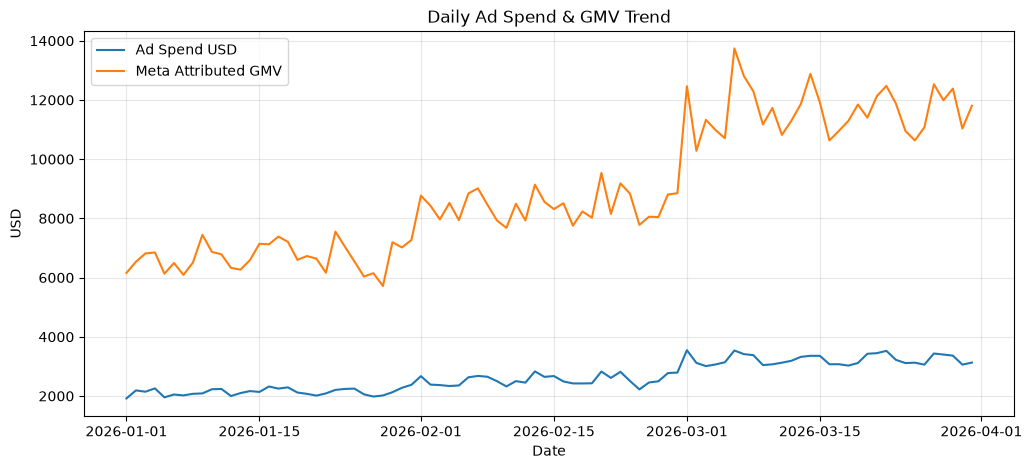

In [10]:
import matplotlib.pyplot as plt

daily_data = df_clean.groupby("Date")[["Spend_USD","Meta_Attributed_GMV_USD"]].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(daily_data['Date'], daily_data['Spend_USD'], label='Ad Spend USD')
plt.plot(daily_data['Date'], daily_data['Meta_Attributed_GMV_USD'], label='Meta Attributed GMV')
plt.title('Daily Ad Spend & GMV Trend')
plt.xlabel('Date')
plt.ylabel('USD')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


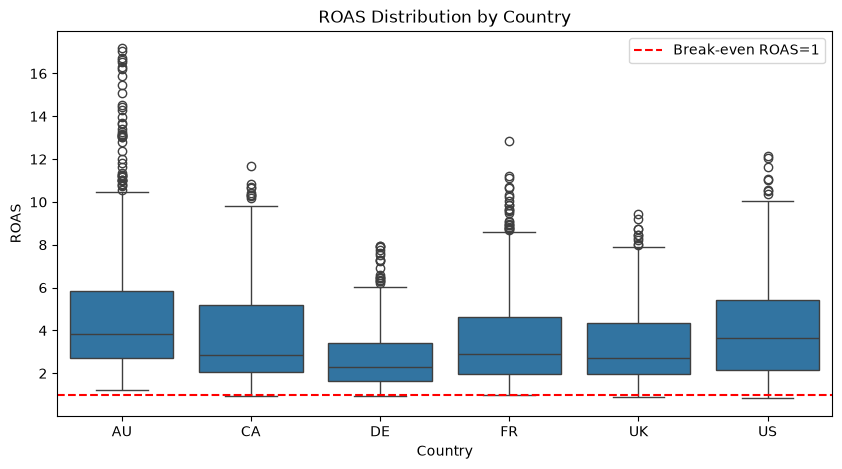

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean, x='Country', y='ROAS')
plt.title('ROAS Distribution by Country')
plt.axhline(y=1, color='red', linestyle='--', label='Break-even ROAS=1')
plt.legend()
plt.show()


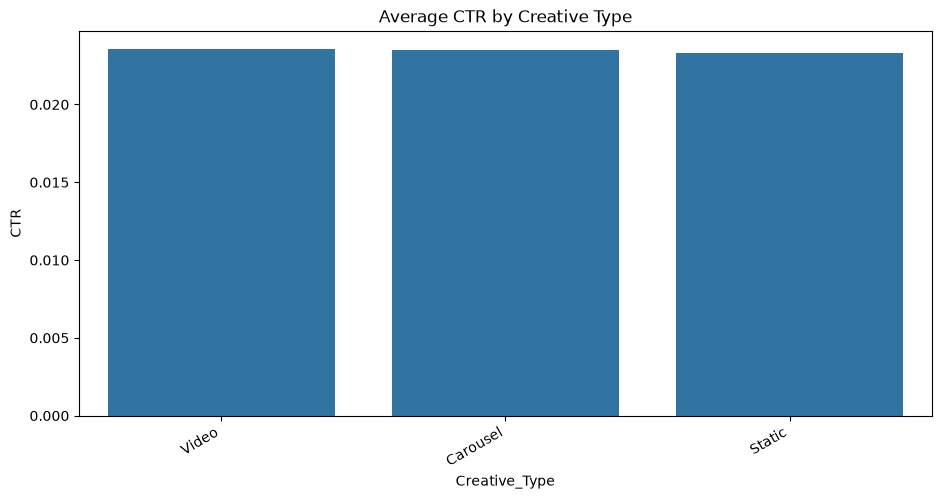

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

creative_ctr = df_clean.groupby("Creative_Type")['CTR'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(11,5))
sns.barplot(data=creative_ctr, x='Creative_Type', y='CTR')
plt.title('Average CTR by Creative Type')
plt.xticks(rotation=30, ha='right')
plt.show()


四、用户转化漏斗分析
1. 分析目标
基于Q1 Meta广告全链路用户行为指标，搭建「曝光 - 点击 - 落地页 - 加购 - 发起结账 - 购买」6层转化漏斗，定位用户流失的关键节点，找到转化卡点。

2. 漏斗结果解读
(1) 整体广告CTR为2.24%，符合出海泳装品类Meta广告行业基准；点击跳转落地页转化率86.08%，落地页访问链路通畅，不存在跳转、加载阻塞问题。
(2) 核心流失节点：落地页进入商品页到加入购物车环节，转化率仅9.78%**。大量用户浏览商品页后，没有加入购物车。推测诱因：商品定价、尺码参考、商品图文说服力不足，无法打动用户加购。
(3) 加购→发起结账、发起结账→最终购买两个环节转化率稳定，证明结账流程、海外支付链路不存在明显卡点，付款环节不是转化瓶颈。

3. 优化建议
重点优化商品详情页，迭代商品文案、尺码指引模块、买家秀实拍素材，提升落地页至加购环节转化率；可以小范围测试定价策略、捆绑优惠活动，降低用户下单决策门槛。

/var/folders/_8/sxv0d29n2ws486787zbr1lyh0000gn/T/ipykernel_18474/489925488.py:45: UserWarning: Glyph 21344 (\N{CJK UNIFIED IDEOGRAPH-5360}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/_8/sxv0d29n2ws486787zbr1lyh0000gn/T/ipykernel_18474/489925488.py:45: UserWarning: Glyph 26333 (\N{CJK UNIFIED IDEOGRAPH-66DD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/_8/sxv0d29n2ws486787zbr1lyh0000gn/T/ipykernel_18474/489925488.py:45: UserWarning: Glyph 20809 (\N{CJK UNIFIED IDEOGRAPH-5149}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/_8/sxv0d29n2ws486787zbr1lyh0000gn/T/ipykernel_18474/489925488.py:45: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/_8/sxv0d29n2ws486787zbr1lyh0000gn/T/ipykernel_18474/489925488.py:45: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/_8/sxv0d29n2

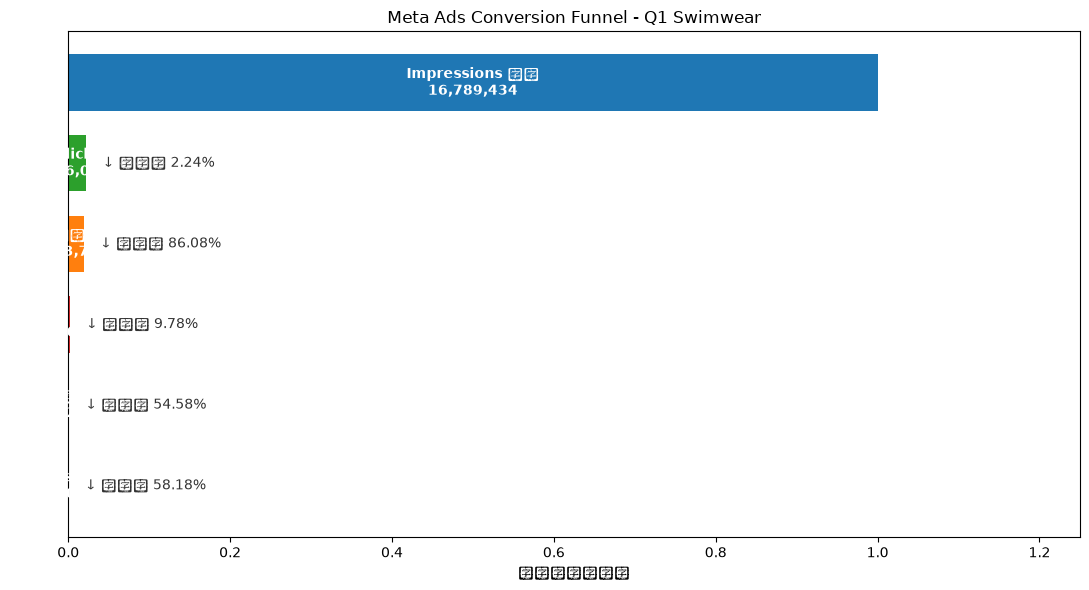

===== 漏斗各层转化率 =====
Impressions 曝光 → Link Clicks 点击：2.24%
Link Clicks 点击 → LPV 落地页浏览：86.08%
LPV 落地页浏览 → ATC 加购：9.78%
ATC 加购 → IC 发起结账：54.58%
IC 发起结账 → Purchases 购买：58.18%


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 定义漏斗各层：(显示名称, 表里真实字段名)
funnel_stages = [
    ("Impressions 曝光", "Impressions"),
    ("Link Clicks 点击", "Link_Clicks"),
    ("LPV 落地页浏览", "Landing_Page_Views"),
    ("ATC 加购", "Add_to_Cart"),
    ("IC 发起结账", "Initiate_Checkout"),
    ("Purchases 购买", "Purchases")
]

# 2. 计算每一层的总量（把3588条广告的数值全部加总）
stage_names = [s[0] for s in funnel_stages]
stage_values = [df_clean[s[1]].sum() for s in funnel_stages]

# 3. 计算每层相对上一层的转化率
conv_rates = [1.0] + [stage_values[i] / stage_values[i-1] for i in range(1, len(stage_values))]

# 4. 画漏斗（用横向条形图模拟，最顶层最宽）
fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(stage_names))
max_val = stage_values[0]
bar_lengths = [v / max_val for v in stage_values]   # 归一化到 0~1

colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd', '#17becf']
bars = ax.barh(y_pos, bar_lengths, color=colors, height=0.7)
ax.invert_yaxis()   # 让曝光在最上面

# 5. 每个条上标注：层名 + 总量；右侧标注相对上一层转化率
for i, (bar, val, rate) in enumerate(zip(bars, stage_values, conv_rates)):
    ax.text(bar.get_width()/2, bar.get_y()+bar.get_height()/2,
            f"{stage_names[i]}\n{val:,.0f}",
            ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    if i > 0:
        ax.text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
                f"↓ 转化率 {rate:.2%}",
                ha='left', va='center', color='#333', fontsize=10)

ax.set_xlim(0, 1.25)
ax.set_yticks([])
ax.set_title("Meta Ads Conversion Funnel - Q1 Swimwear")
ax.set_xlabel("占曝光量的比例")
plt.tight_layout()
plt.show()

# 6. 打印漏斗每层转化率表格，方便写结论
print("===== 漏斗各层转化率 =====")
for i in range(1, len(stage_names)):
    print(f"{stage_names[i-1]} → {stage_names[i]}：{conv_rates[i]:.2%}")


五、A/B测试：视频素材 vs 静态素材 点击率显著性检验
1. 实验背景
基于出海泳装Meta广告历史投放数据，评估广告创意类型（视频素材/静态图片素材）对广告点击率CTR的影响。
- 对照组：Static静态图片素材
- 实验组：Video视频素材
- 评估指标：CTR = 点击量 ÷ 曝光量
- 检验方法：两样本比例Z检验，显著性水平 α=0.05

2. 假设定义
H₀（原假设）：视频素材与静态素材CTR不存在统计学显著差异
H₁（备择假设）：视频素材CTR显著高于静态素材

3. 实验结果
(1) 静态素材平均CTR：2.330%；视频素材平均CTR：2.357%
(2) Z统计量=2.8694，P值=0.0041，P < 0.05，**拒绝原假设**
(3) 统计结论：在当前数据集下，视频广告素材点击率显著优于静态图片素材。

4. 局限说明
本分析属于**历史观测数据回测，并非线上流量随机分流的正式A/B实验**，无法完全消除受众人群、预算分配、投放时段等混杂变量带来的干扰，结论仅作为业务决策参考；如果想要严格验证素材的因果效应，需要搭建受众随机分配的线上A/B实验。


Static平均CTR: 2.330%
Video平均CTR: 2.357%

Z统计量=2.8694, P值=0.0041
拒绝原假设：两组CTR存在显著差异


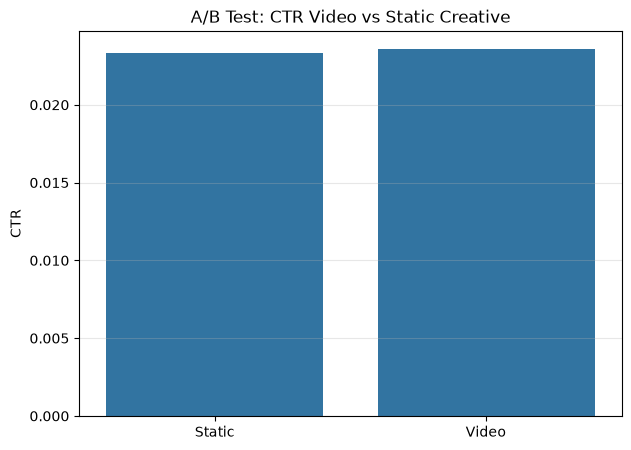

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

df = df_clean.copy()
df_ab = df[df["Creative_Type"].isin(["Video", "Static"])]

# 计算每条广告CTR
df_ab["CTR"] = df_ab["Link_Clicks"] / df_ab["Impressions"]

# 拆分两组
static = df_ab[df_ab["Creative_Type"] == "Static"]["CTR"]
video = df_ab[df_ab["Creative_Type"] == "Video"]["CTR"]

# 两组均值
mean_static = static.mean()
mean_video = video.mean()
print(f"Static平均CTR: {mean_static:.3%}")
print(f"Video平均CTR: {mean_video:.3%}")

# 两样本Z检验
n1, n2 = len(static), len(video)
p1 = mean_static
p2 = mean_video
p_pool = (static.sum() + video.sum())/(df_ab["Impressions"].sum())
se = (p_pool*(1-p_pool)*(1/n1 +1/n2))**0.5
z_stat = (p2-p1)/se
p_value = 2*(1-norm.cdf(abs(z_stat)))

print(f"\nZ统计量={z_stat:.4f}, P值={p_value:.4f}")
alpha=0.05
if p_value<alpha:
    print("拒绝原假设：两组CTR存在显著差异")
else:
    print("不能拒绝原假设：两组CTR差异不显著")

# 绘图
plt.figure(figsize=(7,5))
sns.barplot(x=["Static","Video"],y=[mean_static,mean_video])
plt.title("A/B Test: CTR Video vs Static Creative")
plt.ylabel("CTR")
plt.grid(axis='y',alpha=0.3)
plt.show()


六、项目总结与投放优化建议
1. 项目整体总结
本项目完成Q1季度Meta广告全链路复盘，从宏观投放收益、用户转化漏斗、创意素材统计检验三个角度完成分析。
整体投放盈利，但市场之间效果差距明显；广告曝光跳转落地页链路流畅，**最大转化瓶颈在落地页到加购阶段**；统计检验证明视频素材点击率显著高于静态素材。

2. 业务策略建议
(1) 增加澳大利亚市场预算倾斜，持续放大优质市场收益
(2) 对德国市场低效广告组进行关停、素材迭代，减少无效广告消耗
(3) 后续新增创意优先生产视频类素材，降低静态素材投放占比
(4) 优化商品详情页内容，解决落地页到加购环节高流失问题，提升整体转化
